In [ ]:
!pip install pandas scikit-learn xgboost bambi arviz matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
import pymc as pm
import arviz as az

# Load dataset
df = pd.read_csv("dementia_dataset.csv")

# Preprocessing
categorical = ['Group', 'M/F', 'Hand']
continuous = ['Age', 'MMSE', 'SES', 'CDR', 'nWBV', 'ASF', 'eTIV']

# Encode target
df['Target'] = df['Group'].apply(lambda x: 1 if x == 'Demented' else 0)

# Feature Engineering
df['Age_squared'] = df['Age']**2
df['Age_MMSE'] = df['Age'] * df['MMSE']
df['CDR_nWBV'] = df['CDR'] * df['nWBV']
df = df.sort_values(['Subject ID', 'Visit'])  # Ensure temporal order
df['MMSE_baseline'] = df.groupby('Subject ID')['MMSE'].transform('first')
df['MMSE_change'] = df['MMSE'] - df['MMSE_baseline']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous + ['Age_squared', 'Age_MMSE', 'CDR_nWBV', 'MMSE_change']),
        ('cat', categorical_transformer, categorical)])

X = df[continuous + categorical + ['Age_squared', 'Age_MMSE', 'CDR_nWBV', 'MMSE_change']]
y = df['Target']

# Preprocess data
X_processed = preprocessor.fit_transform(X)

# Gradient Boosted Trees
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Stacking ensemble
stack_model = StackingClassifier(
    estimators=[('xgb', xgb_model)],
    final_estimator=LogisticRegression())

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in skf.split(X_processed, y):
    X_train, X_test = X_processed[train_index], X_processed[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    stack_model.fit(X_train, y_train)
    y_pred = stack_model.predict(X_test)

    # Evaluate model (metrics can be added here)

# GLMM model with PyMC (simplified)
with pm.Model() as model:
    age = pm.Data('age', df['Age'])
    mmse = pm.Data('mmse', df['MMSE'])
    subject = pm.Data('subject', df['Subject ID'].astype('category').cat.codes)
    target = pm.Data('target', y)

    intercept = pm.Normal('intercept', mu=0, sigma=1)
    beta_age = pm.Normal('beta_age', mu=0, sigma=1)
    beta_mmse = pm.Normal('beta_mmse', mu=0, sigma=1)
    sigma_u = pm.Exponential('sigma_u', 1)
    u = pm.Normal('u', mu=0, sigma=sigma_u, shape=len(np.unique(subject)))

    mu = intercept + beta_age * age + beta_mmse * mmse + u[subject]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    y_obs = pm.Bernoulli('y_obs', p=p, observed=target)

    trace = pm.sample(1000, tune=1000, target_accept=0.95)

# Diagnostics
az.plot_trace(trace)



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

# Load dataset
df = pd.read_csv("dementia_dataset.csv")

# Encode target
df['Target'] = df['Group'].apply(lambda x: 1 if x == 'Demented' else 0)

# Feature Engineering
df['Age_squared'] = df['Age'] ** 2
df['Age_MMSE'] = df['Age'] * df['MMSE']
df['CDR_nWBV'] = df['CDR'] * df['nWBV']
df = df.sort_values(['Subject ID', 'Visit'])  # Ensure temporal order
df['MMSE_baseline'] = df.groupby('Subject ID')['MMSE'].transform('first')
df['MMSE_change'] = df['MMSE'] - df['MMSE_baseline']

# Define variables
categorical = ['Group', 'M/F', 'Hand']
continuous = ['Age', 'MMSE', 'SES', 'CDR', 'nWBV', 'ASF', 'eTIV']
engineered = ['Age_squared', 'Age_MMSE', 'CDR_nWBV', 'MMSE_change']
features = continuous + categorical + engineered
target = 'Target'

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, continuous + engineered),
    ('cat', categorical_transformer, categorical)])

# Prepare data
X = df[features]
y = df[target]
X_processed = preprocessor.fit_transform(X)

# LASSO Logistic Regression
lasso_model = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    cv=5,
    scoring='roc_auc',
    max_iter=1000,
    random_state=42
)
lasso_model.fit(X_processed, y)

# Print LASSO coefficients
coef_names = preprocessor.get_feature_names_out()
lasso_coefficients = pd.Series(lasso_model.coef_[0], index=coef_names)
print("\nLASSO Coefficients (non-zero):")
print(lasso_coefficients[lasso_coefficients != 0])

# XGBoost model
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Stacking ensemble (LASSO + XGBoost)
stack_model = StackingClassifier(
    estimators=[('lasso', lasso_model), ('xgb', xgb_model)],
    final_estimator=LogisticRegression(),
    cv=5
)

# Cross-validation and evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_index, test_index) in enumerate(skf.split(X_processed, y), 1):
    print(f"\n--- Fold {fold} ---")
    X_train, X_test = X_processed[train_index], X_processed[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    stack_model.fit(X_train, y_train)
    y_pred = stack_model.predict(X_test)
    y_prob = stack_model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))



LASSO Coefficients (non-zero):
num__MMSE                -0.207762
num__Age_MMSE            -0.114542
num__CDR_nWBV             1.237326
cat__Group_Demented       5.384401
cat__Group_Nondemented   -0.584006
dtype: float64

--- Fold 1 ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        29

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

AUC: 1.0

--- Fold 2 ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        29

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

AUC: 1.0

--- Fold 3 ---


...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        29

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74

AUC: 1.0

--- Fold 5 ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        29

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74

AUC: 1.0


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:46:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


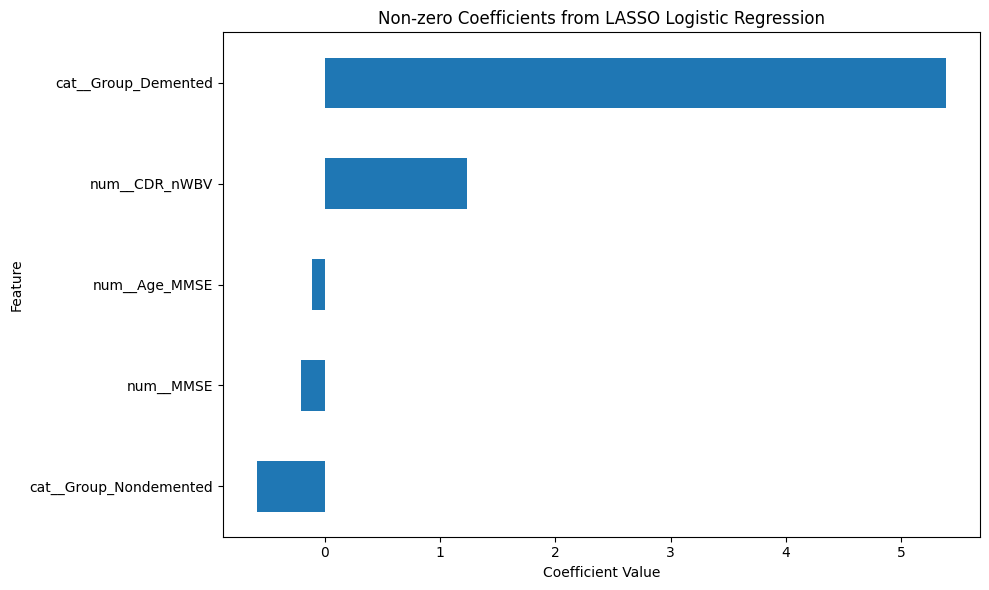

In [ ]:
import matplotlib.pyplot as plt

# Plot non-zero LASSO coefficients
nonzero_coefs = lasso_coefficients[lasso_coefficients != 0].sort_values()

plt.figure(figsize=(10, 6))
nonzero_coefs.plot(kind='barh')
plt.title("Non-zero Coefficients from LASSO Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Sort non-zero coefficients by absolute magnitude
top_features = lasso_coefficients[lasso_coefficients != 0].abs().sort_values(ascending=False)

# Show top N features (e.g., top 10)
top_n = 10
print(f"\nTop {top_n} features from LASSO Logistic Regression:")
print(top_features.head(top_n))


Top 10 features from LASSO Logistic Regression:
cat__Group_Demented       5.384401
num__CDR_nWBV             1.237326
cat__Group_Nondemented    0.584006
num__MMSE                 0.207762
num__Age_MMSE             0.114542
dtype: float64


In [ ]:
import pandas as pd
# Load the most recent dementia dataset again
df = pd.read_csv("dementia_dataset.csv")

# Filter to keep only the last visit per Subject
df_sorted = df.sort_values(by=["Subject ID", "Visit"])
df_last_visit = df_sorted.groupby("Subject ID").tail(1)

# Exclude 'Converted' group as per BLSME 2023 methodology
df_filtered = df_last_visit[df_last_visit["Group"] != "Converted"]

# Count dementia vs nondementia by gender
summary_table = pd.crosstab(index=df_filtered["M/F"],
                            columns=df_filtered["Group"],
                            margins=True,
                            normalize='index').round(4) * 100

# Also include the count values
count_table = pd.crosstab(index=df_filtered["M/F"],
                          columns=df_filtered["Group"])

# Merge percentage and count tables
summary_combined = count_table.astype(str) + " (" + summary_table.astype(str) + "%)"

# Add totals row
summary_combined.loc["Total"] = count_table.sum().astype(str) + " (" + summary_table.mean().round(2).astype(str) + "%)"

display(summary_combined)


Group,Demented,Nondemented
M/F,,
All,NaN,NaN
F,28 (35.9%),50 (64.1%)
M,36 (62.07%),22 (37.93%)
Total,64 (48.34%),72 (51.66%)


In [ ]:
# Define age bins (60–98, in 5-year intervals)
age_bins = list(range(60, 100, 5))
age_labels = [f"{i}-{i+4}" for i in age_bins[:-1]]

# Create the age group column
df_filtered["Age Group"] = pd.cut(df_filtered["Age"], bins=age_bins, labels=age_labels, right=False)

# Create a table: counts of Demented and Nondemented within each Age Group
age_group_table = pd.crosstab(index=df_filtered["Age Group"],
                              columns=df_filtered["Group"],
                              margins=True)

print(age_group_table)


Group      Demented  Nondemented  All
Age Group                            
60-64             1            4    5
65-69             8            5   13
70-74            11           14   25
75-79            20           16   36
80-84            15           15   30
85-89             6           10   16
90-94             2            6    8
All              63           70  133


/tmp/ipython-input-5-1337319533.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Age Group"] = pd.cut(df_filtered["Age"], bins=age_bins, labels=age_labels, right=False)


<Figure size 1000x600 with 0 Axes>

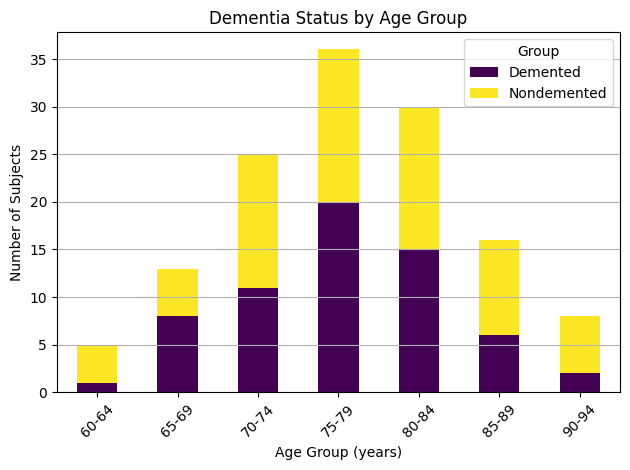

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for histogram: stacked bar for each age group
age_group_counts = pd.crosstab(df_filtered["Age Group"], df_filtered["Group"]).reindex(age_labels)

# Plot histogram
plt.figure(figsize=(10, 6))
age_group_counts.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Dementia Status by Age Group')
plt.xlabel('Age Group (years)')
plt.ylabel('Number of Subjects')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.tight_layout()
plt.grid(axis='y')

# Show plot
plt.show()


<Figure size 600x500 with 0 Axes>

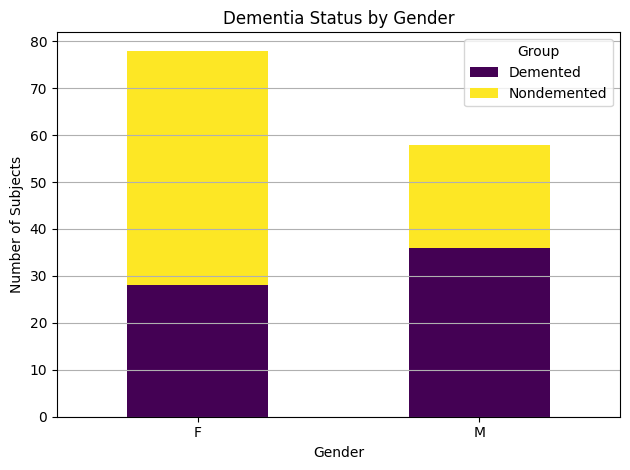

In [ ]:
# Prepare data for gender histogram: stacked counts of Group by M/F
gender_group_counts = pd.crosstab(df_filtered["M/F"], df_filtered["Group"])

# Plot histogram
plt.figure(figsize=(6, 5))
gender_group_counts.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Dementia Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Subjects')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.tight_layout()
plt.grid(axis='y')

# Show plot
plt.show()


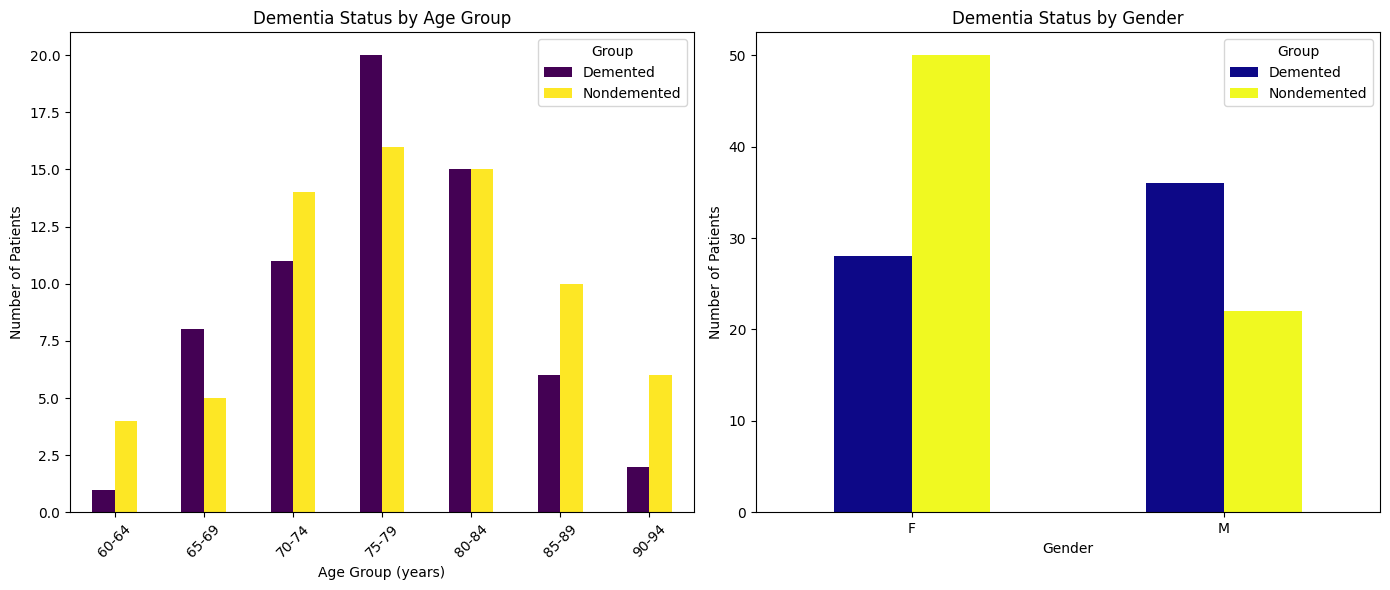

In [ ]:
# Create side-by-side histograms for gender and age group using subplots

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot age group histogram
age_group_counts.plot(kind='bar', stacked=False, colormap='viridis', ax=axes[0])
axes[0].set_title('Dementia Status by Age Group')
axes[0].set_xlabel('Age Group (years)')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y')
axes[0].grid(False)  # Removed grid lines
axes[0].legend(title='Group')

# Plot gender histogram
gender_group_counts.plot(kind='bar', stacked=False, colormap='plasma', ax=axes[1])
axes[1].set_title('Dementia Status by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y')
axes[1].grid(False)  # Removed grid lines
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()


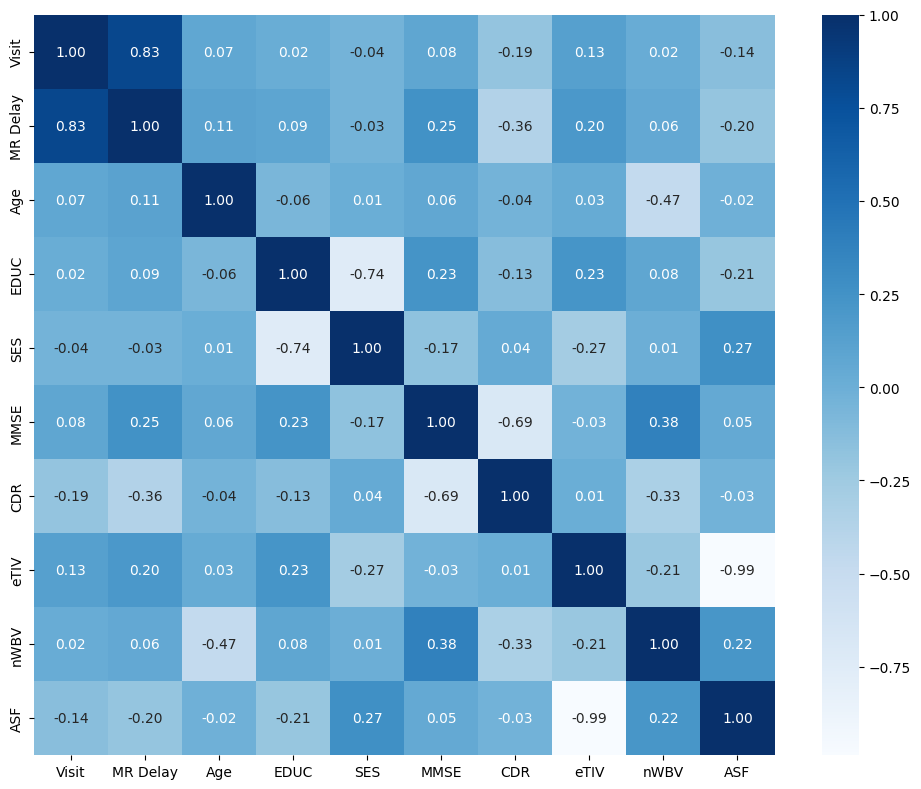

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_cols = df_filtered.select_dtypes(include=["float64", "int64"])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", square=True)
#plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


In [ ]:
# Re-import necessary libraries after code environment reset
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency


# Select the last visit per subject and exclude "Converted"
df_sorted = df.sort_values(by=["Subject ID", "Visit"])
df_last = df_sorted.groupby("Subject ID").tail(1)
df_last = df_last[df_last["Group"] != "Converted"]

# Define dementia label
df_last["Dementia"] = df_last["Group"] == "Demented"

# Prepare output table: variable, value in NO group, value in YES group, p-value
results = []

# Separate continuous and categorical variables
categorical_vars = ["M/F", "SES", "EDUC"]
continuous_vars = ["Age", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]

# Categorical analysis (Chi-squared test)
for var in categorical_vars:
    contingency = pd.crosstab(df_last[var], df_last["Dementia"])
    try:
        _, p, _, _ = chi2_contingency(contingency)
    except:
        p = np.nan
    for level in contingency.index:
        no = contingency.loc[level, False] if False in contingency.columns else 0
        yes = contingency.loc[level, True] if True in contingency.columns else 0
        results.append((f"{var} = {level}", f"{no}", f"{yes}", f"{p:.3f}"))

# Continuous analysis (Mann-Whitney U test)
for var in continuous_vars:
    group_no = df_last[df_last["Dementia"] == False][var].dropna()
    group_yes = df_last[df_last["Dementia"] == True][var].dropna()
    if not group_no.empty and not group_yes.empty:
        stat, p = mannwhitneyu(group_no, group_yes)
        results.append((
            var,
            f"{group_no.median():.2f} ({group_no.quantile(0.25):.2f}-{group_no.quantile(0.75):.2f})",
            f"{group_yes.median():.2f} ({group_yes.quantile(0.25):.2f}-{group_yes.quantile(0.75):.2f})",
            f"{p:.3f}"
        ))

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Variable", "No Dementia", "Yes Dementia", "P-value"])

# Display to user
print(results_df)


     Variable                No Dementia               Yes Dementia P-value
0     M/F = F                         50                         28   0.004
1     M/F = M                         22                         36   0.004
2   SES = 1.0                         15                         11   0.273
3   SES = 2.0                         27                         12   0.273
4   SES = 3.0                         16                         15   0.273
5   SES = 4.0                         13                         16   0.273
6   SES = 5.0                          1                          2   0.273
7    EDUC = 6                          0                          1   0.054
8    EDUC = 8                          1                          3   0.054
9   EDUC = 11                          3                          2   0.054
10  EDUC = 12                         13                         26   0.054
11  EDUC = 13                          7                          3   0.054
12  EDUC = 1

In [ ]:
# Re-import required libraries after code execution environment reset
import pandas as pd
import numpy as np


# Load dataset again
df = pd.read_csv("dementia_dataset.csv")

# Select the last visit per subject
df_sorted = df.sort_values(by=["Subject ID", "Visit"])
df_last = df_sorted.groupby("Subject ID").tail(1)

# Consider "Converted" as "Demented"
df_last["Group"] = df_last["Group"].replace("Converted", "Demented")

# Separate groups
df_demented = df_last[df_last["Group"] == "Demented"]
df_nondemented = df_last[df_last["Group"] == "Nondemented"]

# Prepare summary table
summary = []

# Total counts
summary.append(["Number", f"{len(df_nondemented)}", f"{len(df_demented)}"])

# Age (Mean ± SD)
summary.append(["Age (Mean ± SD)",
                f"{df_nondemented['Age'].mean():.2f} ± {df_nondemented['Age'].std():.2f}",
                f"{df_demented['Age'].mean():.2f} ± {df_demented['Age'].std():.2f}"])

# Female sex (%)
female_nd = (df_nondemented["M/F"] == "F").sum()
female_d = (df_demented["M/F"] == "F").sum()
summary.append(["Female sex (%)",
                f"{female_nd} ({female_nd / len(df_nondemented) * 100:.1f}%)",
                f"{female_d} ({female_d / len(df_demented) * 100:.1f}%)"])

# MMSE (Mean ± SD)
summary.append(["MMSE (Mean ± SD)",
                f"{df_nondemented['MMSE'].mean():.2f} ± {df_nondemented['MMSE'].std():.2f}",
                f"{df_demented['MMSE'].mean():.2f} ± {df_demented['MMSE'].std():.2f}"])

# CDR (Mean ± SD)
summary.append(["CDR (Mean ± SD)",
                f"{df_nondemented['CDR'].mean():.2f} ± {df_nondemented['CDR'].std():.2f}",
                f"{df_demented['CDR'].mean():.2f} ± {df_demented['CDR'].std():.2f}"])

# eTIV (Mean ± SD)
summary.append(["eTIV (Mean ± SD)",
                f"{df_nondemented['eTIV'].mean():.2f} ± {df_nondemented['eTIV'].std():.2f}",
                f"{df_demented['eTIV'].mean():.2f} ± {df_demented['eTIV'].std():.2f}"])

# nWBV (Mean ± SD)
summary.append(["nWBV (Mean ± SD)",
                f"{df_nondemented['nWBV'].mean():.3f} ± {df_nondemented['nWBV'].std():.3f}",
                f"{df_demented['nWBV'].mean():.3f} ± {df_demented['nWBV'].std():.3f}"])

# ASF (Mean ± SD)
summary.append(["ASF (Mean ± SD)",
                f"{df_nondemented['ASF'].mean():.3f} ± {df_nondemented['ASF'].std():.3f}",
                f"{df_demented['ASF'].mean():.3f} ± {df_demented['ASF'].std():.3f}"])

# Create DataFrame
summary_df = pd.DataFrame(summary, columns=["Variable", "No Dementia", "Demented"])

# Display to user

print(summary_df)


           Variable       No Dementia          Demented
0            Number                72                78
1   Age (Mean ± SD)      78.72 ± 8.15      78.10 ± 7.24
2    Female sex (%)        50 (69.4%)        38 (48.7%)
3  MMSE (Mean ± SD)      29.17 ± 0.98      24.52 ± 4.74
4   CDR (Mean ± SD)       0.00 ± 0.00       0.69 ± 0.35
5  eTIV (Mean ± SD)  1488.43 ± 191.59  1481.74 ± 167.86
6  nWBV (Mean ± SD)     0.734 ± 0.039     0.712 ± 0.035
7   ASF (Mean ± SD)     1.198 ± 0.150     1.199 ± 0.133


/tmp/ipython-input-2-3495887859.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last["Group"] = df_last["Group"].replace("Converted", "Demented")


In [ ]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.0 MB/s eta 0:00:00


In [6]:
# Install boruta package if not already installed
# !pip install boruta

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.preprocessing import LabelEncoder

# Load your dataset
data = pd.read_csv('dementia_dataset.csv')

# Drop missing values
data = data.dropna()

# Encode target variable
target = 'Group'  # Replace with your actual target column name
le = LabelEncoder()
data[target] = le.fit_transform(data[target])

# Split into features and labels
X = data.drop(columns=[target])
y = data[target].values

# Encode categorical features if any
X_encoded = pd.get_dummies(X, drop_first=True)

# Define Random Forest Classifier for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

# Initialize Boruta
boruta_selector = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=1)

# Fit Boruta
boruta_selector.fit(X_encoded.values, y)

# Get selected feature names
selected_features = X_encoded.columns[boruta_selector.support_].tolist()

print("Selected Features by Boruta:")
print(selected_features)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	505
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	495
Iteration: 	9 / 100
Confirmed: 	4
Tentative: 	6
Rejected: 	495
Iteration: 	10 / 100
Confirmed: 	4
Tentative: 	6
Rejected: 	495
Iteration: 	11 / 100
Confirmed: 	4
Tentative: 	6
Rejected: 	495
Iteration: 	12 / 100
Confirmed: 	5
Tentative: 	4
Rejected: 	496
Iteration: 	13 / 100
Confirmed: 	5
Tentative: 	4
Rejected: 	496
Iteration: 	14 / 100
Confirmed: 	5
Tentative: 	4
Rejected: 	496
Iteration: 	15 / 100
Confirmed: 	5
Tentative: 	4
Rejected: 	496
Iteration: 	16 / 100
Confirmed: 	5
Tentative: 	3

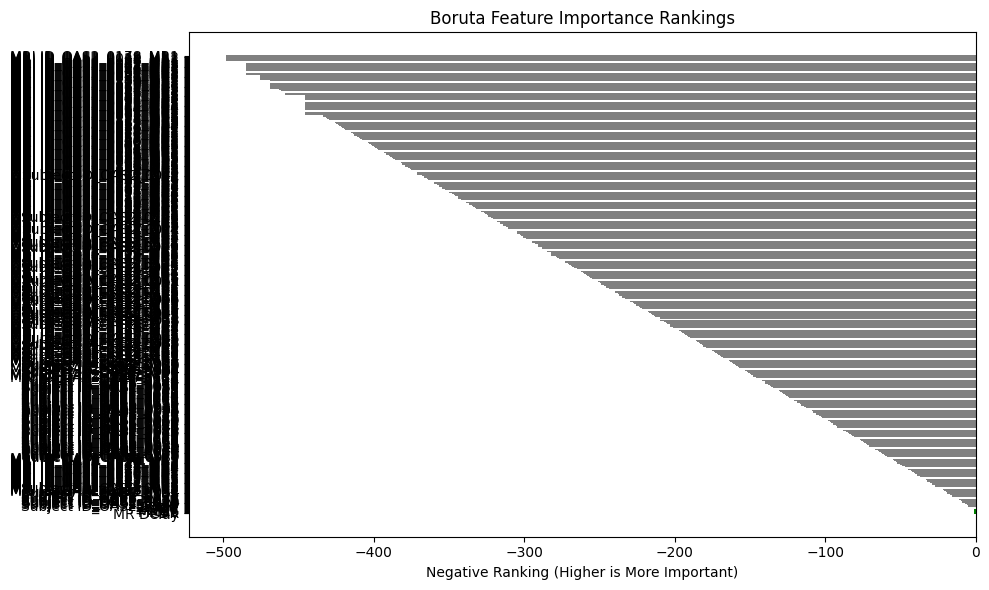

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from Boruta
importances = boruta_selector.ranking_
feature_names = X_encoded.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': importances,
    'Selected': boruta_selector.support_
}).sort_values(by='Ranking')

# Plot the rankings
plt.figure(figsize=(10, 6))
colors = ['green' if sel else 'gray' for sel in importance_df['Selected']]
plt.barh(importance_df['Feature'], -importance_df['Ranking'], color=colors)
plt.xlabel('Negative Ranking (Higher is More Important)')
plt.title('Boruta Feature Importance Rankings')
plt.tight_layout()
plt.show()


Selected features by LASSO: ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV']
Random Forest CV Accuracy: 94.35% ± 2.37%

Feature Importances:
     Feature  Importance
6       CDR    0.517789
5      MMSE    0.212246
1  MR Delay    0.063396
8      nWBV    0.061943
7      eTIV    0.040094
2       Age    0.036969
3      EDUC    0.032900
4       SES    0.021851
0     Visit    0.012812


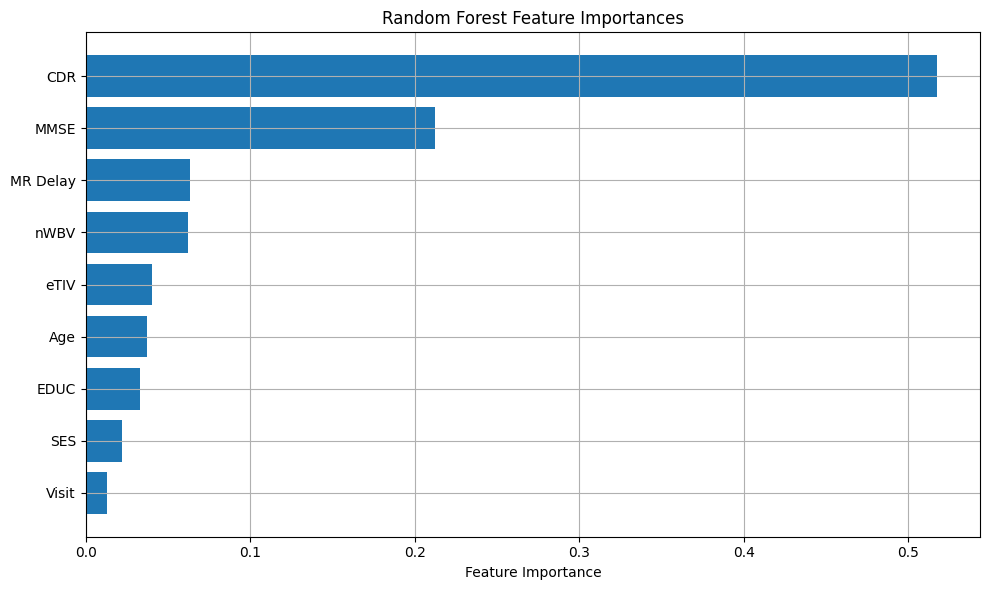

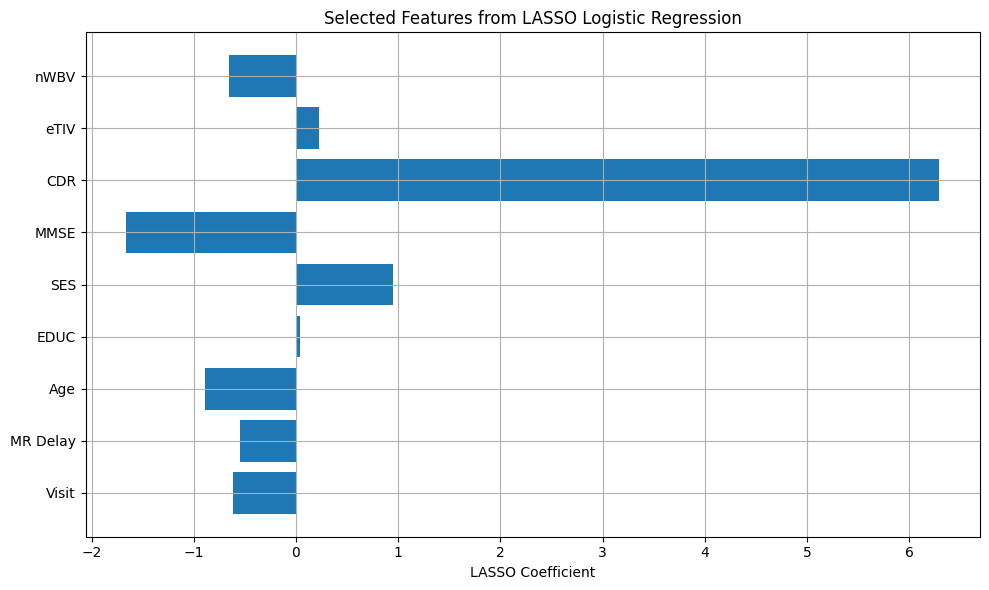

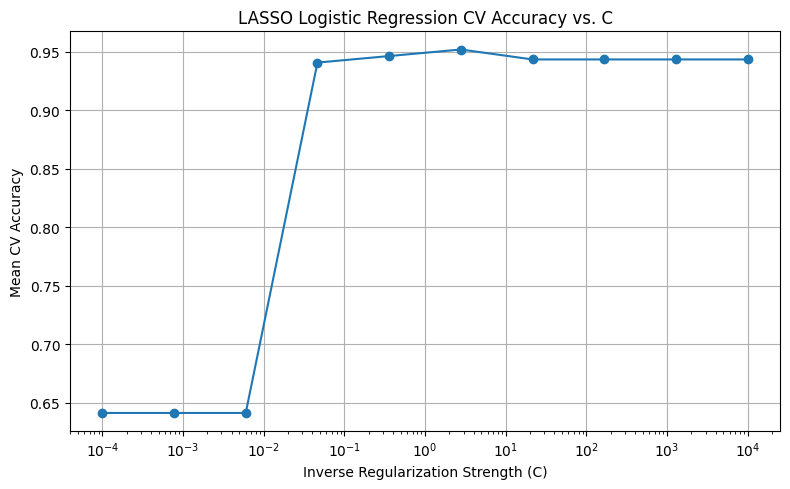

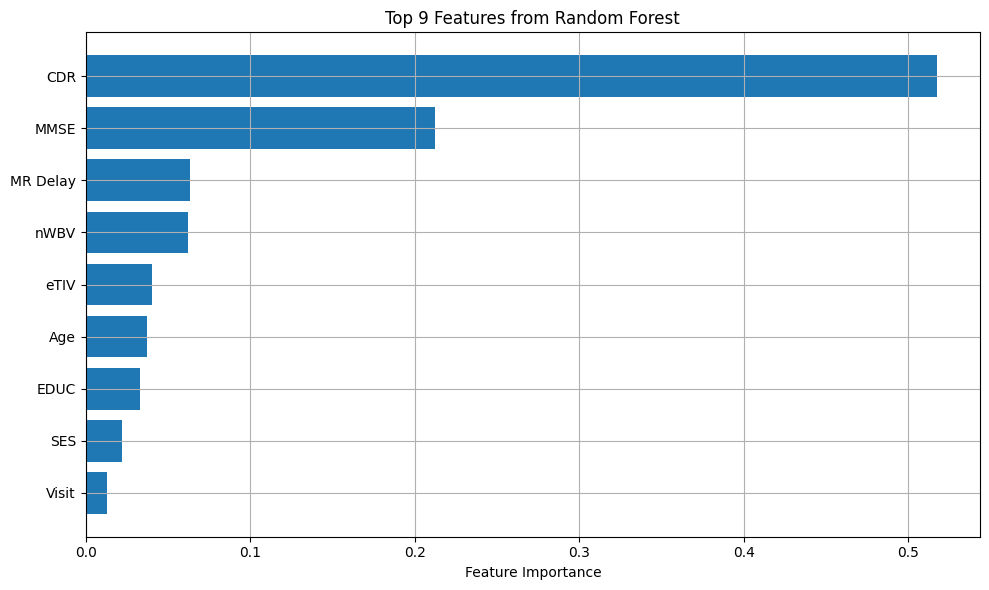

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("dementia_dataset.csv")

# Data cleaning
df = df.drop(columns=["Subject ID", "MRI ID", "Hand", "M/F"])
df["Group"] = df["Group"].apply(lambda x: 1 if x == "Demented" else 0)
df = df.dropna()

# Prepare predictors and response
X = df.drop(columns="Group")
y = df["Group"]
X_encoded = pd.get_dummies(X, drop_first=True)

# Standardize predictors for LASSO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# LASSO logistic regression with cross-validation
lasso_cv = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='saga',
    scoring='accuracy', max_iter=10000, random_state=42
)
lasso_cv.fit(X_scaled, y)

# Extract non-zero coefficients
coef = lasso_cv.coef_.flatten()
selected_features = X_encoded.columns[coef != 0]

# Subset the data using selected features
X_selected = X_encoded[selected_features]

# Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_model, X_selected, y, cv=5, scoring='accuracy')
rf_model.fit(X_selected, y)

# Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Print results
print("Selected features by LASSO:", selected_features.tolist())
print("Random Forest CV Accuracy: {:.2f}% ± {:.2f}%".format(cv_scores.mean()*100, cv_scores.std()*100))
print("\nFeature Importances:\n", feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Plot the coefficients of the selected features
plt.figure(figsize=(10, 6))
selected_coef = coef[coef != 0]
plt.barh(selected_features, selected_coef)
plt.xlabel("LASSO Coefficient")
plt.title("Selected Features from LASSO Logistic Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

# Create additional plots: cross-validation curve for LASSO and top 10 features bar plot for clarity

# 1. Cross-validation curve for LASSO
plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.Cs_, lasso_cv.scores_[1].mean(axis=0), marker='o')
plt.xscale('log')
plt.xlabel("Inverse Regularization Strength (C)")
plt.ylabel("Mean CV Accuracy")
plt.title("LASSO Logistic Regression CV Accuracy vs. C")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Top 10 important features in Random Forest (if more than 10)
top_n = min(10, len(feature_importance_df))
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Features from Random Forest")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


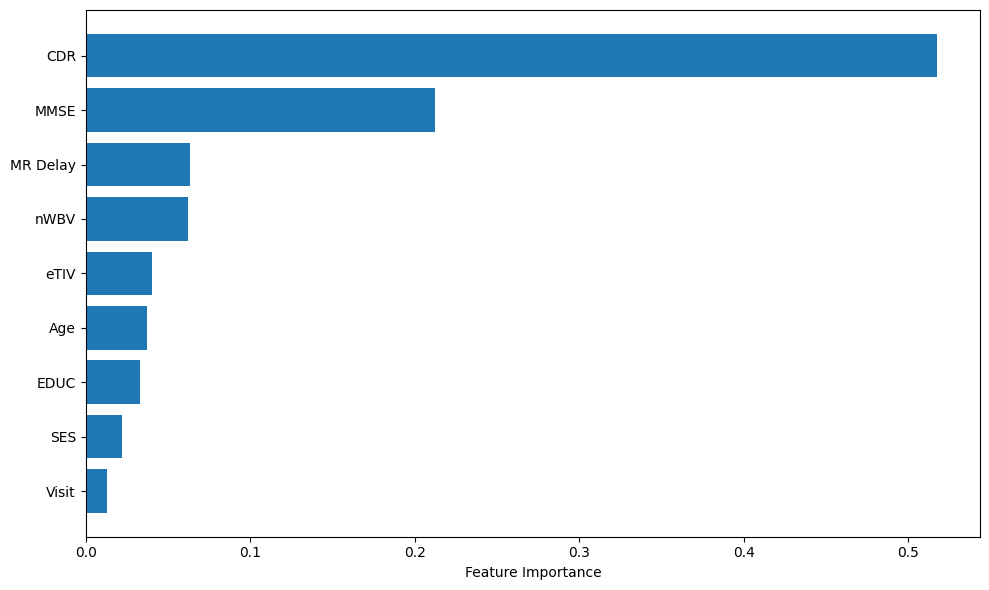

In [4]:
top_n = min(10, len(feature_importance_df))
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
#plt.title(f"Top {top_n} Features from Random Forest")
plt.gca().invert_yaxis()
plt.grid(False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

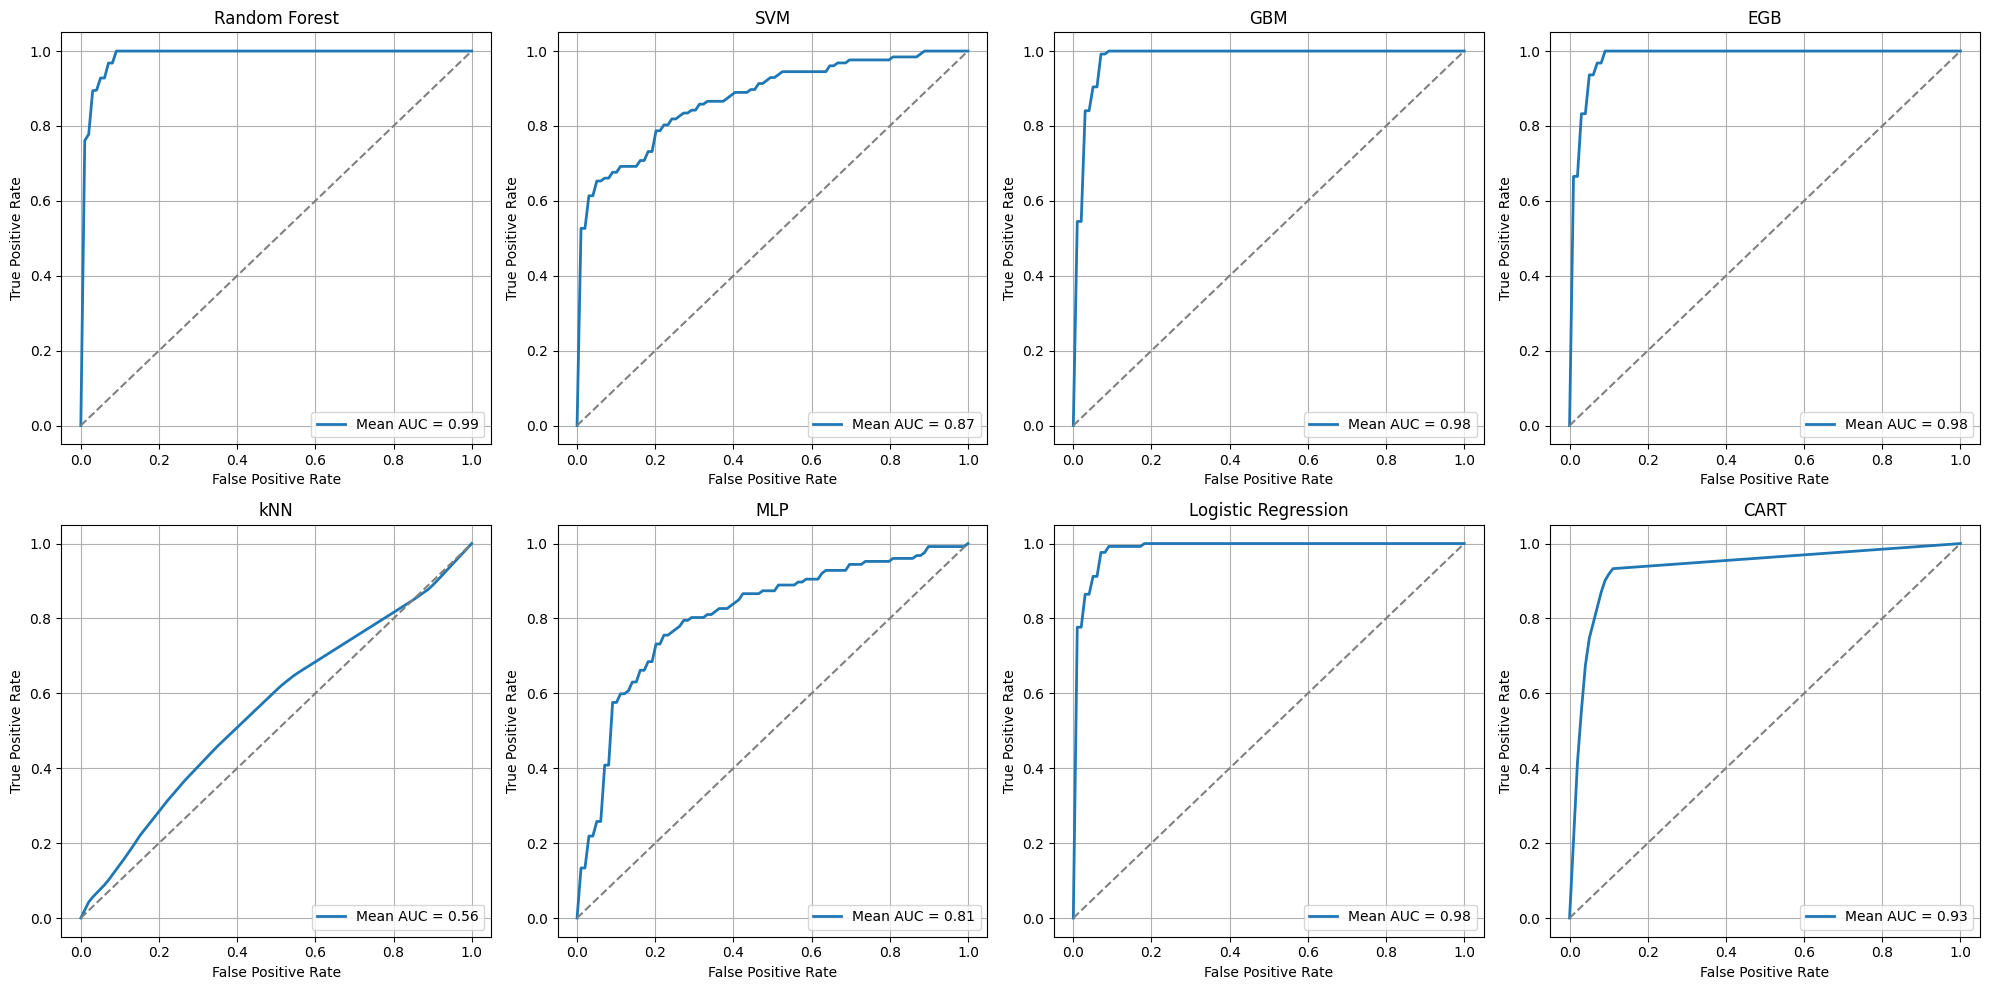

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42),
    "EGB": HistGradientBoostingClassifier(random_state=42),
    "kNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "CART": DecisionTreeClassifier(random_state=42)
}

# Initialize 5-fold stratified cross-validator
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plotting setup
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Loop through each model
for i, (name, model) in enumerate(models.items()):
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X_selected, y):
        model.fit(X_selected.iloc[train_idx], y.iloc[train_idx])
        probas_ = model.predict_proba(X_selected.iloc[test_idx])[:, 1]
        fpr, tpr, _ = roc_curve(y.iloc[test_idx], probas_)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

    # Mean TPR
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)

    # Plot
    ax = axes[i]
    ax.plot(mean_fpr, mean_tpr, label=f'Mean AUC = {mean_auc:.2f}', lw=2)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

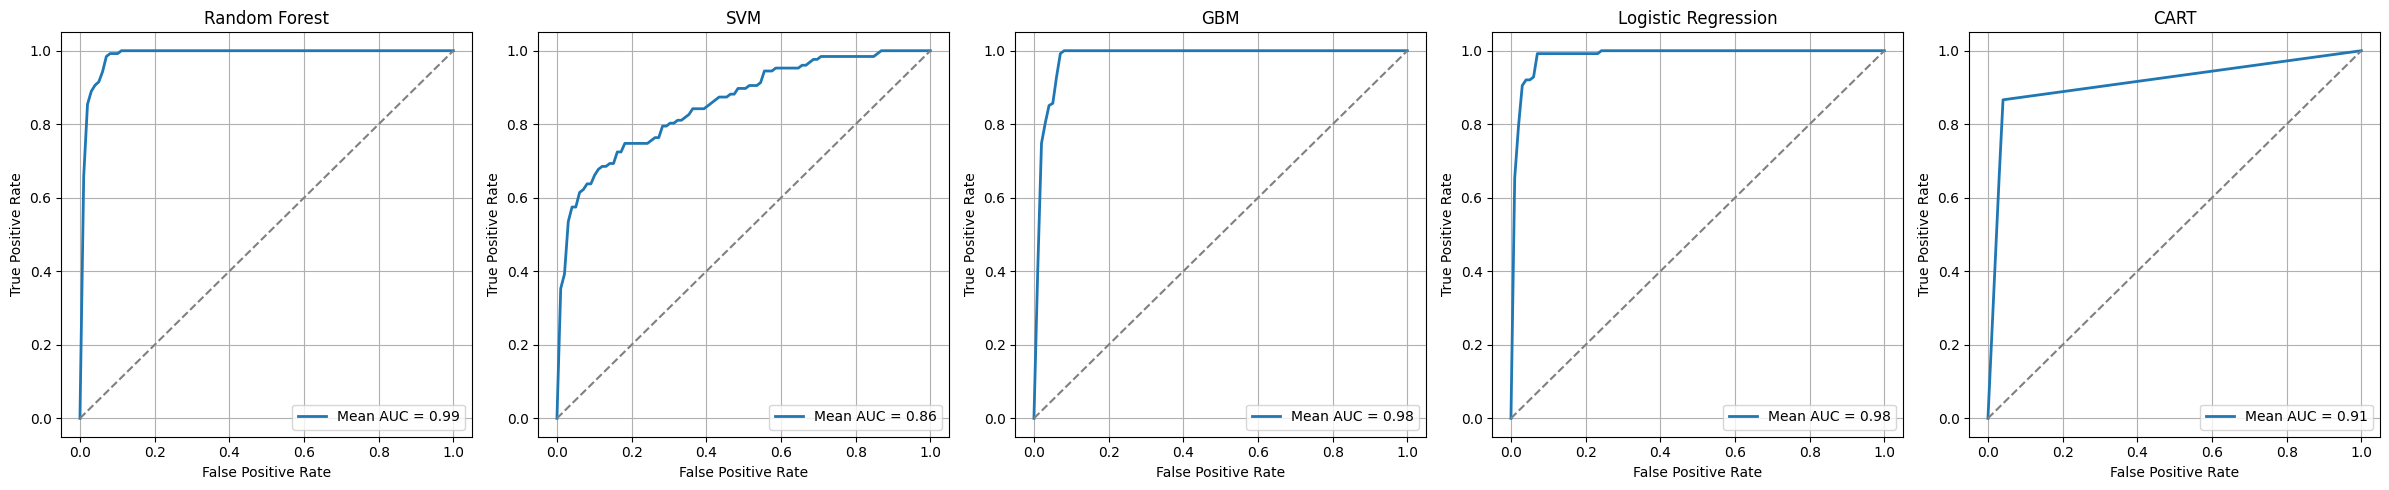

In [14]:
# Reduce to 5 efficient models and use 3-fold CV for speed
models_reduced = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "CART": DecisionTreeClassifier(random_state=42)
}

# 3-fold stratified cross-validator
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Plotting setup
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes = axes.flatten()

# Loop through each model
for i, (name, model) in enumerate(models_reduced.items()):
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X_selected, y):
        model.fit(X_selected.iloc[train_idx], y.iloc[train_idx])
        probas_ = model.predict_proba(X_selected.iloc[test_idx])[:, 1]
        fpr, tpr, _ = roc_curve(y.iloc[test_idx], probas_)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

    # Mean TPR and AUC
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)

    # Plot
    ax = axes[i]
    ax.plot(mean_fpr, mean_tpr, label=f'Mean AUC = {mean_auc:.2f}', lw=2)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.show()


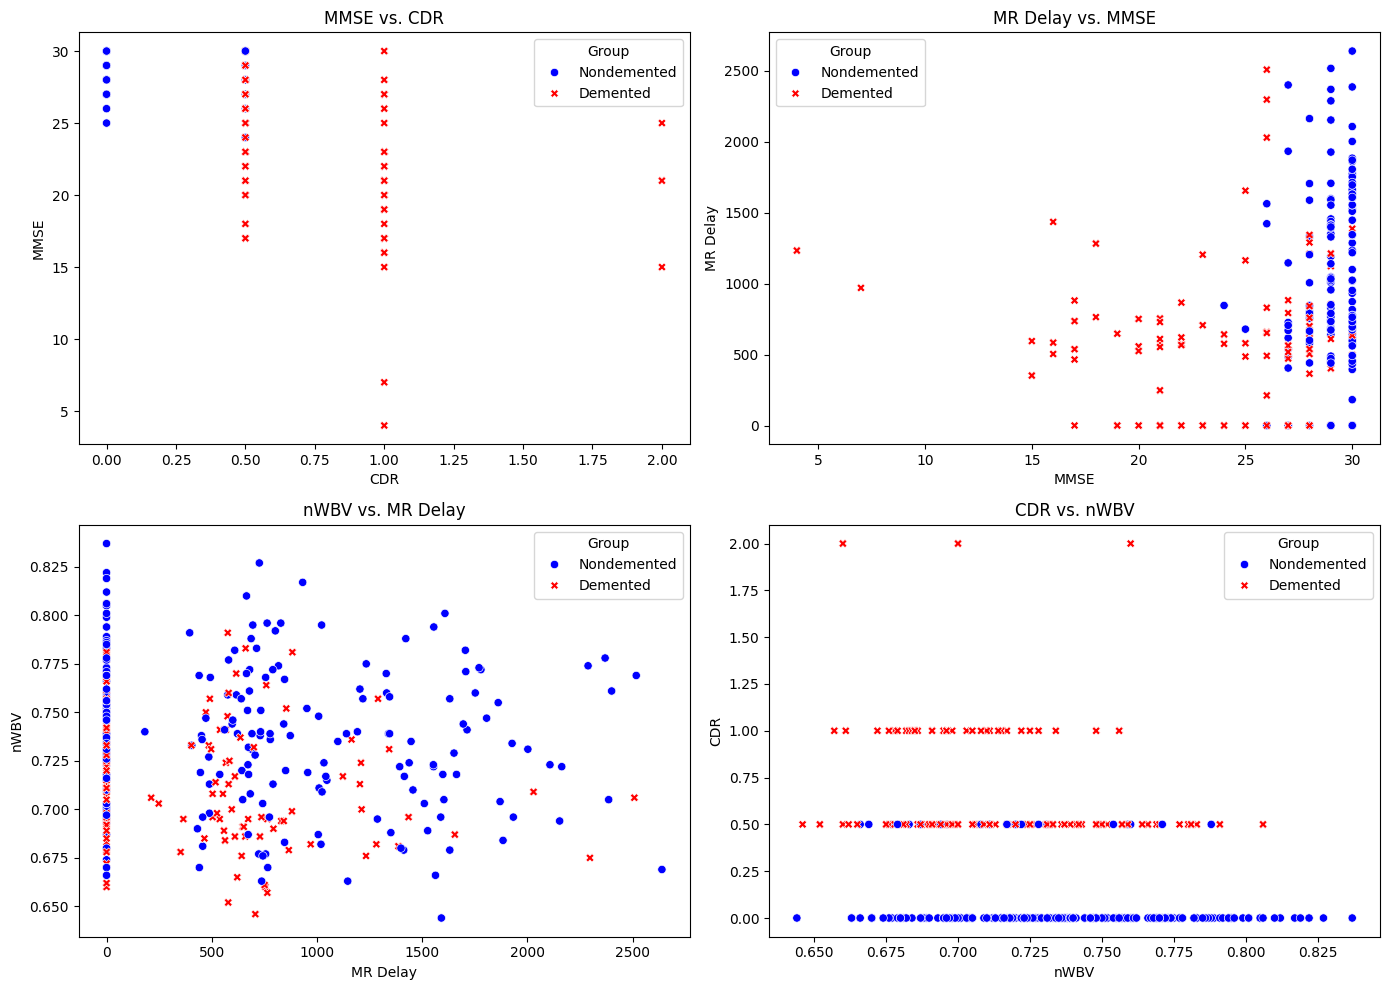

In [19]:
import seaborn as sns

# Get top 4 features by importance
top4_features = feature_importance_df.head(4)["Feature"].tolist()

# Add dementia group to plot data
plot_data = X_selected[top4_features].copy()
plot_data["Group"] = y.replace({0: "Nondemented", 1: "Demented"})

# Prepare subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Create scatter plots for each pairwise comparison between top 4 features
for i in range(4):
    x_feat = top4_features[i]
    y_feat = top4_features[(i + 1) % 4]  # rotate
    ax = axes[i]
    sns.scatterplot(
        data=plot_data,
        x=x_feat,
        y=y_feat,
        hue="Group",
        style="Group",
        palette={"Demented": "red", "Nondemented": "blue"},
        ax=ax
    )
    ax.set_title(f"{y_feat} vs. {x_feat}")
    ax.grid(False)

plt.tight_layout()
plt.show()


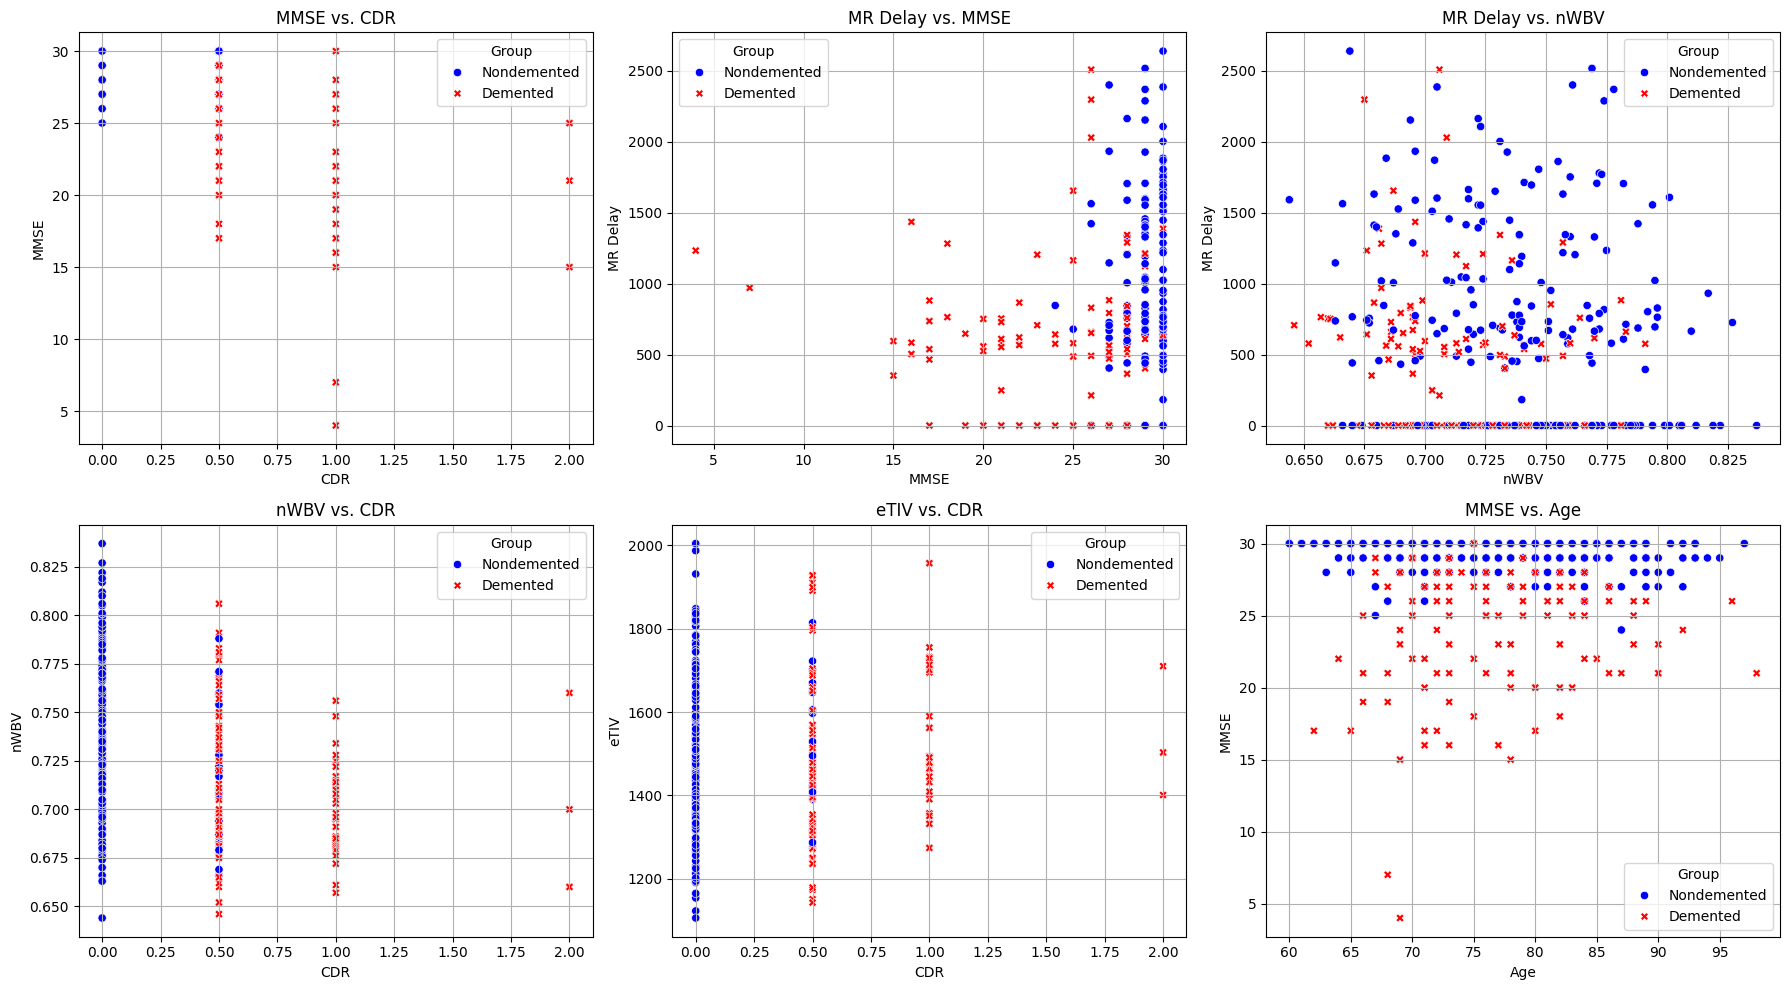

In [20]:
# Select six features for comparison
top6_features = feature_importance_df.head(6)["Feature"].tolist()

# Prepare pair combinations (we'll take 6 meaningful pairs manually to avoid memory issues)
pair_combinations = [
    ("CDR", "MMSE"),
    ("MMSE", "MR Delay"),
    ("nWBV", "MR Delay"),
    ("CDR", "nWBV"),
    ("CDR", "eTIV"),
    ("Age", "MMSE")
]

# Add group labels
plot_data6 = X_selected[top6_features].copy()
plot_data6["Group"] = y.replace({0: "Nondemented", 1: "Demented"})

# Create subplots for selected feature pairs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Generate scatter plots
for i, (x_feat, y_feat) in enumerate(pair_combinations):
    ax = axes[i]
    sns.scatterplot(
        data=plot_data6,
        x=x_feat,
        y=y_feat,
        hue="Group",
        style="Group",
        palette={"Demented": "red", "Nondemented": "blue"},
        ax=ax
    )
    ax.set_title(f"{y_feat} vs. {x_feat}")
    ax.grid(True)

plt.tight_layout()
plt.show()
